# Notebook de Pipeline de IA — Predicción y Segmentación
## Caso SITP / TransMilenio (Portal Eldorado)

**Curso:** CIA6041 — Inteligencia Artificial y Gestión de Datos Organizacionales
**Programa:** Maestría en Ingeniería de Software en Inteligencia Artificial — Broward International University (BIU)
**Docente:** Ph.D. Jhony Andrés Guzmán Henao
**Estudiante:** Oscar Fabián Pedraza García
**Entrega:** SEM8 · Tarea de asignación #8 — *Producto aplicado 2: Pipeline de IA para predicción y segmentación* (20 % de la nota final)
**Caso de estudio:** Sistema Integrado de Transporte Público de Bogotá (SITP) / TransMilenio — estación **Portal Eldorado**

---

### Qué hace este notebook

Este notebook continúa directamente el trabajo de la Tarea 7 (ETL y EDA) y lo lleva a la fase de modelado. Contiene, en un solo documento reproducible:

1. **ETL y EDA** (condensados; el detalle exhaustivo de cada decisión de limpieza está en el notebook de la Tarea 7 y no se repite aquí punto por punto, pero **sí se reproduce en código** para que este notebook corra de forma autónoma).
2. **Un modelo supervisado** — árbol de decisión — comparado siempre contra una **línea base**, con su **matriz de confusión**.
3. **Un modelo no supervisado** — K-Means — con **segmentación nombrada** y su **índice de silueta declarado tal como resulta**.
4. **Interpretación en celda de texto después de cada gráfico o métrica**: qué muestra, qué decisión cambiaría y qué limitación tiene.
5. Un **informe técnico de juicio profesional** (media página) al final: ¿se recomienda producción? Con cifras.

> Siguiendo la advertencia de la guía de esta tarea: *"un cuaderno que solo entrena modelos y no los juzga obtiene la mitad de la nota — el juicio es el producto"*. Por eso cada bloque de código de esta segunda mitad del notebook viene acompañado de una lectura crítica, no solo del número.

### Decisión central y preguntas analíticas (recordatorio del caso)

- **Decisión central:** priorizar la operación (personal, capacidad, señalización) en los accesos y franjas de mayor flujo de salida en Portal Eldorado.
- **Pregunta de predicción → Sección 5:** ¿se puede anticipar, con datos de calendario y de acceso, si una franja horaria será de "alta demanda"?
- **Pregunta de segmentación → Sección 6:** ¿qué combinaciones (acceso, franja horaria) comparten un perfil de uso similar, y qué acción distinta amerita cada grupo?

### Fuente de datos y advertencia de transparencia

Igual que en la Tarea 7: la muestra (`raw_portal_eldorado_nov2023.csv`, TRANSMILENIO S.A. / Datos Abiertos Bogotá, CC BY 4.0) se transcribió manualmente porque este entorno no tiene acceso directo al portal oficial. El pipeline de limpieza nunca modifica ese archivo original.

### Cómo ejecutar este notebook

Suba `raw_portal_eldorado_nov2023.csv` a la misma carpeta de Colab (o dentro del repositorio) y ejecute **Entorno de ejecución → Reiniciar y ejecutar todo**. Se probó de punta a punta sin errores (ver el registro de ejecución entregado junto con este archivo). El archivo de datos depurado que exige la rúbrica se genera y se guarda desde este mismo notebook (Sección 4).


## 1. Configuración del entorno

Además del stack ya usado en la Tarea 7 (pandas, NumPy, Matplotlib), esta tarea agrega **scikit-learn**, ya disponible en Google Colab, para el árbol de decisión, la línea base y K-Means.

In [1]:
import io
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report,
)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)
NAVY, TEAL, AMBER, GRAY = "#0b3d5c", "#1f8a70", "#c87a1a", "#666666"

print("Librerías cargadas correctamente.")
print("pandas:", pd.__version__, "| numpy:", np.__version__)
import sklearn
print("scikit-learn:", sklearn.__version__)


Librerías cargadas correctamente.
pandas: 3.0.2 | numpy: 2.4.4
scikit-learn: 1.8.0


## 2. Carga y limpieza (ETL condensado)

Se reproduce aquí, de forma completa pero más concisa que en la Tarea 7, el mismo pipeline ya validado: cargar el archivo crudo sin modificarlo, corregir la codificación, acotar el alcance a los accesos con extracción completa, transformar de formato ancho a largo y derivar las variables de calendario. Las cifras de calidad (duplicados, vacíos, atípicos) fueron ya diagnosticadas a fondo en la Tarea 7 con las cinco preguntas de DAMA-DMBOK; aquí se recalculan (para que el notebook sea autónomo) pero sin repetir cada justificación metodológica.

In [2]:
RAW_PATH = "raw_portal_eldorado_nov2023.csv"

def decodificar(raw_bytes):
    # utf-8 primero; si el archivo llega con otra codificacion, reintenta antes de fallar.
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            return raw_bytes.decode(enc)
        except (UnicodeDecodeError, AttributeError):
            continue
    raise UnicodeDecodeError("utf-8", b"", 0, 1, "no se pudo decodificar")

try:
    with open(RAW_PATH, "rb") as f:
        raw_text = decodificar(f.read())
    print(f"Archivo '{RAW_PATH}' encontrado localmente.")
except FileNotFoundError:
    from google.colab import files  # type: ignore
    print("Archivo no encontrado en el entorno. Súbalo desde su equipo:")
    uploaded = files.upload()
    RAW_PATH = list(uploaded.keys())[0]
    raw_text = decodificar(uploaded[RAW_PATH])

FIXES = {
    "L�nea": "Línea", "Estaci�n": "Estación", "D�A": "DÍA",
    "T�nel": "Túnel", "Alimentaci�n": "Alimentación",
}
for malo, bueno in FIXES.items():
    raw_text = raw_text.replace(malo, bueno)

df_raw = pd.read_csv(io.StringIO(raw_text), sep=";", dtype=str)
df_raw = df_raw.drop(columns=[c for c in df_raw.columns if c.startswith("Unnamed")])

ACCESOS_COMPLETOS = [
    "(03) Acceso Peatonal Oriental", "(04) Acceso Peatonal Occidental",
    "(18) Acceso Peatonal Oriental (Discapacidad)", "(19) Acceso Peatonal Occidental (Discapacidad)",
    "(21) Acceso Túnel PLAT1 Alimentación",
]
n_brutas = len(df_raw)
df_raw = df_raw[df_raw["Acceso de Estación"].isin(ACCESOS_COMPLETOS)].copy()
print(f"Filas brutas: {n_brutas} → filas tras acotar a los 5 accesos con extracción completa: {len(df_raw)}")
print("(2 accesos con extracción incompleta en este entorno quedan fuera del alcance; ver Tarea 7 para el detalle.)")


Archivo 'raw_portal_eldorado_nov2023.csv' encontrado localmente.
Filas brutas: 452 → filas tras acotar a los 5 accesos con extracción completa: 443
(2 accesos con extracción incompleta en este entorno quedan fuera del alcance; ver Tarea 7 para el detalle.)


In [3]:
DIAS_DEL_MES = 30
columnas_dia = [f"DÍA {i:02d}" for i in range(1, DIAS_DEL_MES + 1)]

long_df = df_raw.melt(
    id_vars=["Línea", "Estación", "Acceso de Estación", "MES", "INTERVALO"],
    value_vars=columnas_dia, var_name="dia_col", value_name="salidas_raw",
)
long_df["dia_num"] = long_df["dia_col"].str.extract(r"(\d+)").astype(int)
long_df["fecha"] = long_df["dia_num"].apply(lambda d: date(2023, 11, d))

def parse_salidas(v):
    if pd.isna(v):
        return np.nan
    v = str(v).strip().replace(".", "")
    if v == "" or v.upper() == "X":
        return np.nan
    return int(v)

long_df["salidas"] = long_df["salidas_raw"].apply(parse_salidas)

bounds = long_df.groupby(["Acceso de Estación", "INTERVALO"])["salidas"].apply(
    lambda s: pd.Series({"low": s.quantile(0.25) - 1.5 * (s.quantile(0.75) - s.quantile(0.25)),
                          "high": s.quantile(0.75) + 1.5 * (s.quantile(0.75) - s.quantile(0.25))})
).unstack()
long_df = long_df.merge(bounds, on=["Acceso de Estación", "INTERVALO"], how="left")
long_df["es_atipico"] = (long_df["salidas"] < long_df["low"]) | (long_df["salidas"] > long_df["high"])

datos = long_df.rename(columns={
    "Línea": "linea", "Estación": "estacion", "Acceso de Estación": "acceso", "INTERVALO": "intervalo",
})[["linea", "estacion", "acceso", "fecha", "intervalo", "salidas", "es_atipico"]].copy()
datos["salidas"] = datos["salidas"].fillna(0).astype(int)
datos["es_atipico"] = datos["es_atipico"].fillna(False).astype(bool)
datos = datos.sort_values(["acceso", "fecha", "intervalo"]).reset_index(drop=True)

print(f"Filas en formato largo (base del análisis): {len(datos)}")
print(f"Duplicados en la clave acceso+fecha+intervalo: {datos.duplicated(subset=['acceso','fecha','intervalo']).sum()}")
print(f"% de observaciones atípicas (IQR por acceso+intervalo): {datos['es_atipico'].mean()*100:.2f} %")
datos.head(3)


Filas en formato largo (base del análisis): 13290
Duplicados en la clave acceso+fecha+intervalo: 0
% de observaciones atípicas (IQR por acceso+intervalo): 2.68 %


,linea,estacion,acceso,fecha,intervalo,salidas,es_atipico
0,(11) Zona K Calle 26,(06000) Portal Eldorado,(03) Acceso Peatonal Oriental,2023-11-01,00:00,13,True
1,(11) Zona K Calle 26,(06000) Portal Eldorado,(03) Acceso Peatonal Oriental,2023-11-01,00:15,5,False
2,(11) Zona K Calle 26,(06000) Portal Eldorado,(03) Acceso Peatonal Oriental,2023-11-01,00:30,6,False


## 3. Variables de calendario derivadas

Estas son las variables que usarán los dos modelos: hora del día (numérica, para que el árbol pueda partir por rangos), día de la semana y bandera de fin de semana.

In [4]:
DIAS_ES = {0: "lunes", 1: "martes", 2: "miércoles", 3: "jueves", 4: "viernes", 5: "sábado", 6: "domingo"}
datos["fecha"] = pd.to_datetime(datos["fecha"])
datos["dia_semana_num"] = datos["fecha"].dt.dayofweek
datos["dia_semana"] = datos["dia_semana_num"].map(DIAS_ES)
datos["es_fin_de_semana"] = datos["dia_semana_num"] >= 5
datos["hora_decimal"] = datos["intervalo"].str.split(":").apply(lambda x: int(x[0]) + int(x[1]) / 60)

print("Variables agregadas: dia_semana_num, dia_semana, es_fin_de_semana, hora_decimal")
datos[["fecha", "dia_semana", "es_fin_de_semana", "acceso", "intervalo", "hora_decimal", "salidas"]].sample(4, random_state=42)


Variables agregadas: dia_semana_num, dia_semana, es_fin_de_semana, hora_decimal


,fecha,dia_semana,es_fin_de_semana,acceso,intervalo,hora_decimal,salidas
7234,2023-11-22,miércoles,False,(18) Acceso Peatonal Oriental (Discapacidad),13:30,13.50,0
9898,2023-11-22,miércoles,False,(19) Acceso Peatonal Occidental (Discapacidad),19:30,19.50,0
1373,2023-11-16,jueves,False,(03) Acceso Peatonal Oriental,11:15,11.25,127
385,2023-11-05,domingo,True,(03) Acceso Peatonal Oriental,09:00,9.00,58


## 4. Archivo de datos depurado (entregable de la rúbrica)

Se guarda como un archivo nuevo — nunca se sobrescribe el CSV original — para acompañar esta entrega, tal como exige la rúbrica ("se acompaña del archivo de datos depurado").

In [5]:
RUTA_DEPURADO = "sitp_portal_eldorado_depurado_tarea8.csv"
datos.to_csv(RUTA_DEPURADO, index=False, encoding="utf-8")
print(f"Archivo depurado guardado en: {RUTA_DEPURADO}  ({len(datos)} filas, {datos.shape[1]} columnas)")
print("El archivo original 'raw_portal_eldorado_nov2023.csv' no fue modificado.")


Archivo depurado guardado en: sitp_portal_eldorado_depurado_tarea8.csv  (13290 filas, 11 columnas)
El archivo original 'raw_portal_eldorado_nov2023.csv' no fue modificado.


## 5. Recordatorio rápido de EDA (detalle completo en la Tarea 7)

Tres hechos ya establecidos en la Tarea 7, que son la base de las decisiones de modelado de las secciones 6 y 7: (1) el acceso "Túnel PLAT1 Alimentación" concentra ~53 % del flujo; (2) hay un pico claro hacia las 07:45 a.m.; (3) el flujo entre semana es ~63 % más alto que el fin de semana. Aquí solo se recalculan los números para dejar constancia, sin repetir los tres gráficos completos.

In [6]:
resumen_acceso = datos.groupby("acceso")["salidas"].sum().sort_values(ascending=False)
print("Participación por acceso:")
print((resumen_acceso / resumen_acceso.sum() * 100).round(1).astype(str) + " %")

prom_semana = datos.loc[~datos["es_fin_de_semana"], "salidas"].mean()
prom_finde = datos.loc[datos["es_fin_de_semana"], "salidas"].mean()
print(f"\nPromedio entre semana: {prom_semana:.1f} | fin de semana: {prom_finde:.1f} "
      f"(+{(prom_semana/prom_finde-1)*100:.0f} %)")

franja_pico = datos.groupby("intervalo")["salidas"].mean().idxmax()
print(f"Franja de mayor salida promedio: {franja_pico}")


Participación por acceso:
acceso
(21) Acceso Túnel PLAT1 Alimentación              53.0 %
(03) Acceso Peatonal Oriental                     31.6 %
(04) Acceso Peatonal Occidental                   15.1 %
(18) Acceso Peatonal Oriental (Discapacidad)       0.2 %
(19) Acceso Peatonal Occidental (Discapacidad)     0.0 %
Name: salidas, dtype: str

Promedio entre semana: 73.8 | fin de semana: 45.2 (+63 %)
Franja de mayor salida promedio: 07:45


## 6. Modelo supervisado: ¿se puede anticipar una franja de "alta demanda"?

**Pregunta de negocio:** con solo la hora, el día de la semana y el acceso, ¿se puede anticipar si una franja va a estar entre el 25 % de mayor salida de personas de *ese mismo acceso*, para reforzar personal con antelación?

### Definición del target

`alta_demanda = 1` si `salidas` está en el percentil 75 o más **dentro de su propio acceso** (no en el percentil 75 global). Esta decisión es deliberada y evita el error de fuga/atajo trivial más común en este tipo de ejercicio: si el umbral fuera global, el modelo podría "acertar" simplemente aprendiendo qué acceso es (el Túnel PLAT1 por sí solo ya concentra ~53 % del flujo total), sin aprender ningún patrón temporal real. Al normalizar por acceso, la tasa positiva queda balanceada (~25 %) en los tres accesos usados, y el modelo se ve obligado a aprender de la hora y el día.

### Declaración de datos excluidos de este modelo

Los accesos **(18)** y **(19)** (uso exclusivo para personas con discapacidad, de volumen casi nulo) se excluyen explícitamente de este modelo: su percentil 75 degenera a 0 salidas, lo que volvería la etiqueta `alta_demanda` prácticamente inútil (positiva casi todo el tiempo, con cualquier salida mayor a 0). Se documentan aquí y no se ocultan, siguiendo el mismo criterio de transparencia de la Tarea 7.

In [7]:
ACCESOS_MODELO = [
    "(03) Acceso Peatonal Oriental",
    "(04) Acceso Peatonal Occidental",
    "(21) Acceso Túnel PLAT1 Alimentación",
]
accesos_excluidos_modelo = sorted(set(datos["acceso"]) - set(ACCESOS_MODELO))
modelo_df = datos[datos["acceso"].isin(ACCESOS_MODELO)].copy()

p75_por_acceso = modelo_df.groupby("acceso")["salidas"].transform(lambda s: s.quantile(0.75))
modelo_df["alta_demanda"] = (modelo_df["salidas"] >= p75_por_acceso).astype(int)

print("Accesos excluidos de este modelo (volumen casi nulo; P75 degenera a 0):", accesos_excluidos_modelo)
print(f"Filas para modelado: {len(modelo_df)} de {len(datos)} totales")
print("\nTasa positiva de 'alta_demanda' por acceso (debe rondar 25 % en los tres):")
print(modelo_df.groupby("acceso")["alta_demanda"].mean().round(3))


Accesos excluidos de este modelo (volumen casi nulo; P75 degenera a 0): ['(18) Acceso Peatonal Oriental (Discapacidad)', '(19) Acceso Peatonal Occidental (Discapacidad)']
Filas para modelado: 8010 de 13290 totales

Tasa positiva de 'alta_demanda' por acceso (debe rondar 25 % en los tres):
acceso
(03) Acceso Peatonal Oriental           0.251
(04) Acceso Peatonal Occidental         0.252
(21) Acceso Túnel PLAT1 Alimentación    0.253
Name: alta_demanda, dtype: float64


### Separación entrenamiento / prueba — **por fecha, no al azar**

Se separa por **fecha de corte** (24 de noviembre) y no con una muestra aleatoria de filas. Con una separación al azar, cada combinación (acceso, franja) aparecería en ambos conjuntos, y el árbol podría limitarse a memorizar la tabla de valores típicos de esa combinación exacta en vez de aprender un patrón generalizable. Separando por fecha, el modelo se entrena con las primeras ~3.5 semanas y se evalúa contra días que nunca vio, que es la situación realista de producción (predecir el futuro, no interpolar el pasado).

In [8]:
fecha_corte = pd.Timestamp("2023-11-24")
train = modelo_df[modelo_df["fecha"] < fecha_corte].copy()
test = modelo_df[modelo_df["fecha"] >= fecha_corte].copy()
print(f"Entrenamiento: {len(train)} filas ({train['fecha'].min().date()} a {train['fecha'].max().date()})")
print(f"Prueba:        {len(test)} filas ({test['fecha'].min().date()} a {test['fecha'].max().date()})")

X_COLS_NUM = ["hora_decimal", "dia_semana_num"]
X_train = pd.get_dummies(train[X_COLS_NUM + ["acceso"]], columns=["acceso"], drop_first=True)
X_test = pd.get_dummies(test[X_COLS_NUM + ["acceso"]], columns=["acceso"], drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_train, y_test = train["alta_demanda"], test["alta_demanda"]

print("\nVariables del modelo:", list(X_train.columns))
print("(el acceso 03 queda como categoría de referencia de las variables dummy)")


Entrenamiento: 6141 filas (2023-11-01 a 2023-11-23)
Prueba:        1869 filas (2023-11-24 a 2023-11-30)

Variables del modelo: ['hora_decimal', 'dia_semana_num', 'acceso_(04) Acceso Peatonal Occidental', 'acceso_(21) Acceso Túnel PLAT1 Alimentación']
(el acceso 03 queda como categoría de referencia de las variables dummy)


**Interpretación**

- **Qué muestra:** El tamaño de cada conjunto (train/test) y las fechas exactas que cubre cada uno, confirmando que la prueba es un bloque de fechas completamente posterior al entrenamiento.
- **Qué decisión cambiaría:** Si la última semana de noviembre tuviera un evento atípico (por ejemplo, un puente festivo), cambiaría la fecha de corte para que la semana de prueba sea representativa de una semana típica.
- **Qué limitación tiene:** Solo se dispone de un mes de datos: el conjunto de prueba es una sola semana, no varios meses. Eso es evidencia de generalización a corto plazo, no una garantía de que el patrón se sostenga en otro mes o en temporada distinta (diciembre, vacaciones, etc.).

### Línea base

Antes de mirar el árbol, se fija el punto de comparación obligatorio: un clasificador que siempre predice la clase mayoritaria (`No alta demanda`). Cualquier modelo que no supere esto claramente no está aportando valor real.

In [9]:
base = DummyClassifier(strategy="most_frequent", random_state=42)
base.fit(X_train, y_train)
pred_base = base.predict(X_test)
acc_base = accuracy_score(y_test, pred_base)
cm_base = confusion_matrix(y_test, pred_base)

print(f"Línea base ('siempre No alta demanda') — exactitud: {acc_base*100:.2f} %")
print("Matriz de confusión (línea base) [filas=real, columnas=predicho]:")
print(cm_base)
print()
print(classification_report(y_test, pred_base, target_names=["No alta demanda", "Alta demanda"], zero_division=0))


Línea base ('siempre No alta demanda') — exactitud: 72.18 %
Matriz de confusión (línea base) [filas=real, columnas=predicho]:
[[1349    0]
 [ 520    0]]

                 precision    recall  f1-score   support

No alta demanda       0.72      1.00      0.84      1349
   Alta demanda       0.00      0.00      0.00       520

       accuracy                           0.72      1869
      macro avg       0.36      0.50      0.42      1869
   weighted avg       0.52      0.72      0.61      1869



**Interpretación**

- **Qué muestra:** La línea base acierta un 72,18 % solo por predecir siempre "No alta demanda" — porque esa clase es, por construcción, el 75 % de los casos. Su matriz de confusión muestra 0 verdaderos positivos: nunca detecta ni una sola franja de alta demanda.
- **Qué decisión cambiaría:** Este número es el piso que cualquier modelo debe superar con claridad. Un modelo que reporte, por ejemplo, 75 % de exactitud sin compararlo contra este 72,18 % parecería bueno y en realidad casi no aportaría nada.
- **Qué limitación tiene:** La exactitud de la línea base es alta precisamente porque las clases están desbalanceadas (75/25). Por eso no basta con mirar la exactitud del árbol tampoco: hay que mirar si detecta la clase minoritaria, que es la que realmente le importa al negocio (anticipar los picos).

### Árbol de decisión (modelo principal)

Se usa un árbol poco profundo (`max_depth=5`, `min_samples_leaf=20`) como modelo principal: lo bastante simple para dibujarse completo y explicarse a un equipo de operación, y lo bastante expresivo para capturar el patrón de hora + acceso.

In [10]:
arbol = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
arbol.fit(X_train, y_train)
pred_arbol = arbol.predict(X_test)
acc_arbol = accuracy_score(y_test, pred_arbol)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred_arbol, average="binary", zero_division=0)

print(f"Árbol (max_depth=5) — exactitud: {acc_arbol*100:.2f} % | hojas: {arbol.get_n_leaves()} | profundidad: {arbol.get_depth()}")
print(f"Clase 'Alta demanda' — precisión: {prec:.3f} | exhaustividad (recall): {rec:.3f} | F1: {f1:.3f}")
print(f"\nMejora sobre la línea base: +{(acc_arbol-acc_base)*100:.2f} puntos porcentuales de exactitud")


Árbol (max_depth=5) — exactitud: 84.06 % | hojas: 18 | profundidad: 5
Clase 'Alta demanda' — precisión: 0.757 | exhaustividad (recall): 0.629 | F1: 0.687

Mejora sobre la línea base: +11.88 puntos porcentuales de exactitud


**Interpretación**

- **Qué muestra:** El árbol llega a 84,06 % de exactitud frente al 72,18 % de la línea base (+11,88 puntos), con 18 hojas y profundidad 5. La clase 'Alta demanda' tiene precisión 0,757 y exhaustividad 0,629: cuando el árbol predice un pico, acierta 3 de cada 4 veces; detecta algo más de 6 de cada 10 picos reales.
- **Qué decisión cambiaría:** La mejora sobre la línea base es real y suficientemente grande para justificar usar el modelo como apoyo (no reemplazo) de la planeación de turnos: sí aprendió un patrón temporal genuino, no solo la proporción de clases.
- **Qué limitación tiene:** Una exhaustividad de 0,629 significa que 4 de cada 10 franjas de alta demanda real no las detecta (falsos negativos). Para una decisión operativa (reforzar personal), ese error silencioso puede ser más costoso que un falso positivo (reforzar sin necesidad), así que el umbral de decisión podría ajustarse para privilegiar exhaustividad si el costo real de quedarse corto de personal es alto.

### Matriz de confusión del árbol

La exactitud sola esconde en qué tipo de error se equivoca el modelo. La matriz de confusión lo muestra explícitamente.

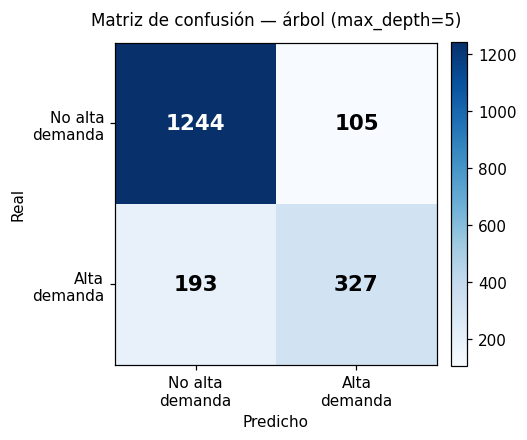

[[VN, FP], [FN, VP]] = [[1244, 105], [193, 327]]


In [11]:
cm_arbol = confusion_matrix(y_test, pred_arbol)
etiquetas = ["No alta\ndemanda", "Alta\ndemanda"]

fig, ax = plt.subplots(figsize=(4.8, 4.3))
im = ax.imshow(cm_arbol, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(etiquetas)
ax.set_yticks([0, 1]); ax.set_yticklabels(etiquetas)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — árbol (max_depth=5)", fontsize=11, pad=12)
for i in range(2):
    for j in range(2):
        color = "white" if cm_arbol[i, j] > cm_arbol.max() / 2 else "black"
        ax.text(j, i, str(cm_arbol[i, j]), ha="center", va="center", color=color, fontsize=14, fontweight="bold")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
print("[[VN, FP], [FN, VP]] =", cm_arbol.tolist())


**Interpretación**

- **Qué muestra:** De las 520 franjas realmente de alta demanda en la semana de prueba, el árbol detecta 327 (verdaderos positivos) y deja pasar 193 (falsos negativos, 37 %). De las 1.349 franjas normales, marca 105 de más como alta demanda (falsos positivos) y clasifica bien 1.244.
- **Qué decisión cambiaría:** Si el costo operativo de un falso negativo (quedar corto de personal en una franja pico real) es mayor que el de un falso positivo (reforzar personal sin necesidad plena), se movería el umbral de decisión del árbol para aceptar más falsos positivos a cambio de menos falsos negativos.
- **Qué limitación tiene:** La matriz resume una sola semana de prueba (1.869 filas); con un desbalance de clases 75/25, incluso un modelo razonable deja una cantidad visible de falsos negativos en términos absolutos aunque su tasa relativa (recall 0,629) sea aceptable.

### Visualización completa del árbol

Se dibuja el árbol completo (no solo la importancia de variables) porque un árbol de 18 hojas todavía puede leerse regla por regla — esa es justamente la ventaja de no usar un modelo más profundo.

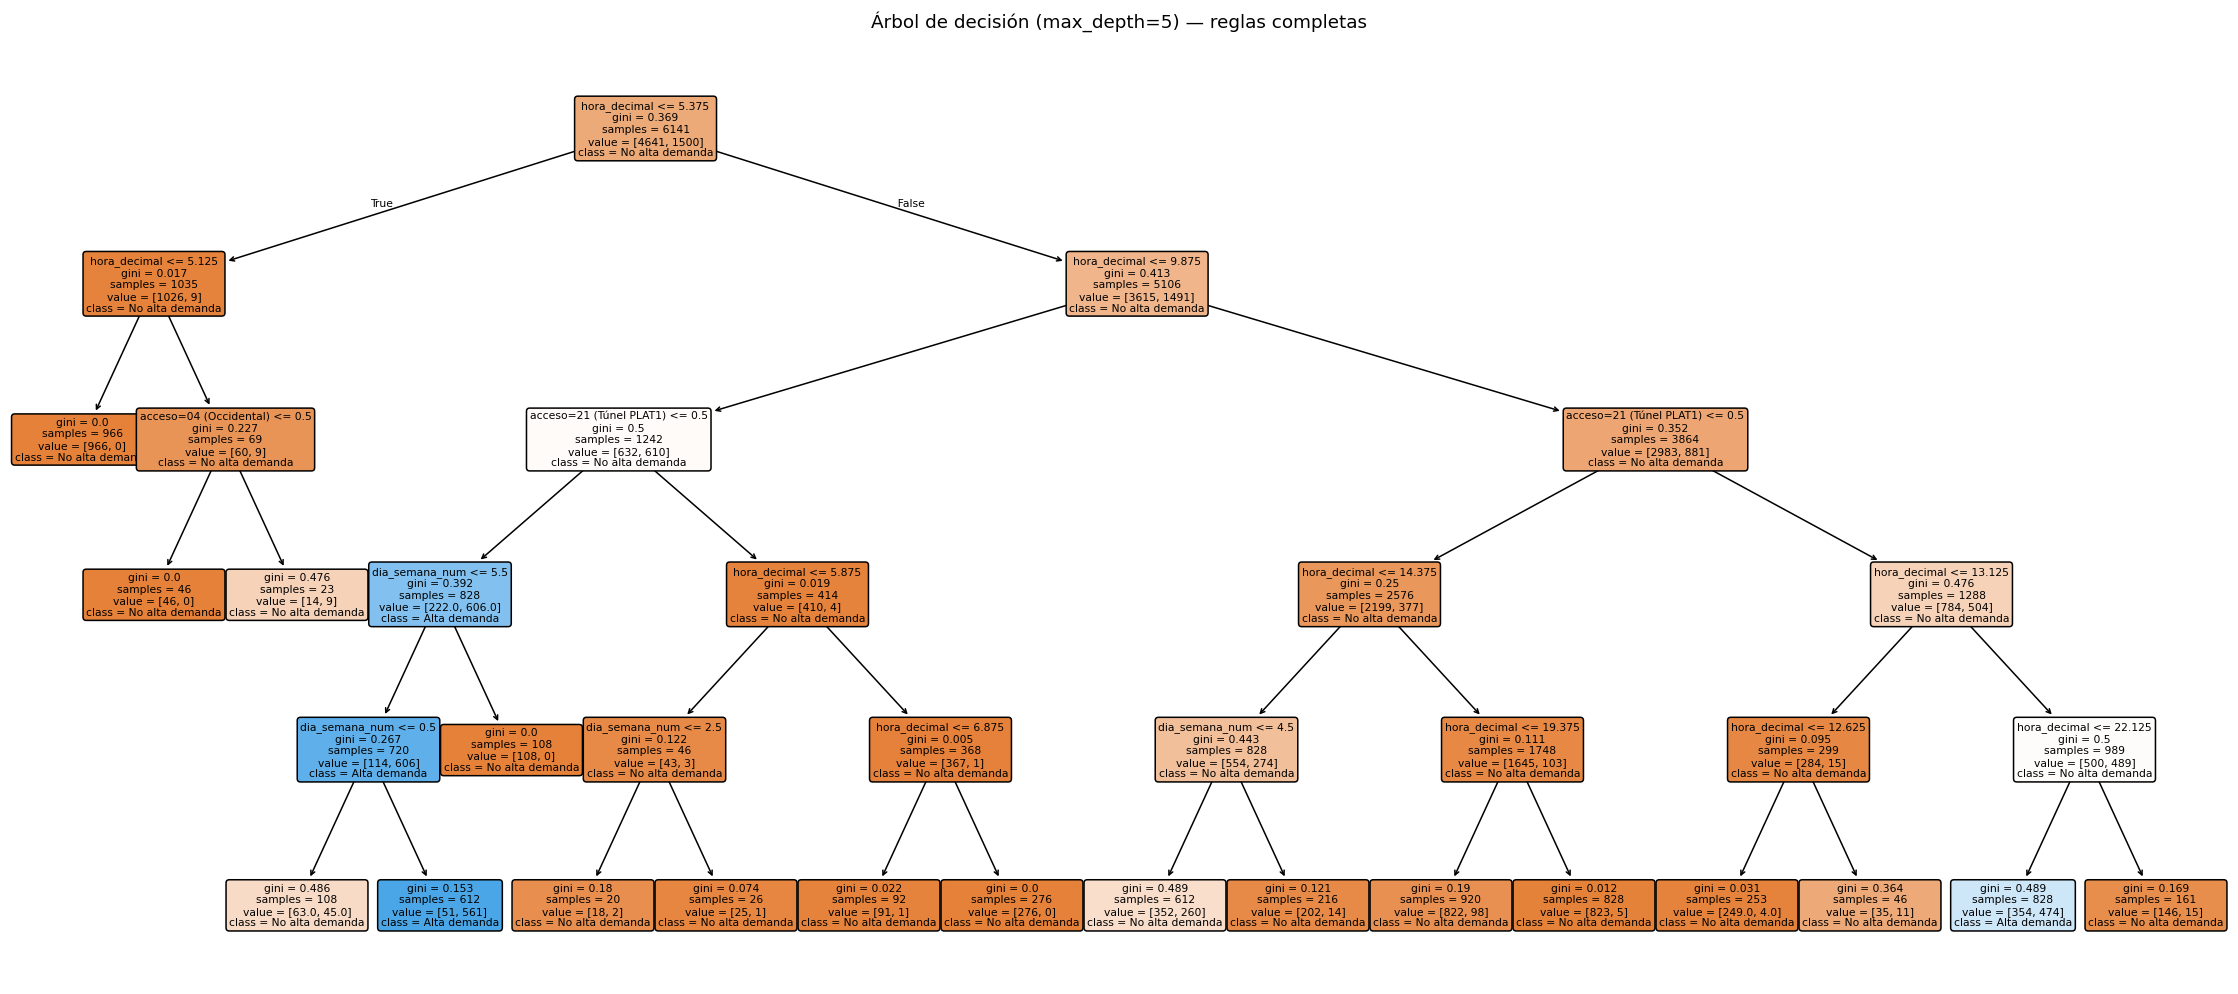

In [12]:
# Etiquetas cortas solo para el dibujo (las columnas reales del modelo no cambian);
# nombres de columna muy largos hacian que las cajas del arbol se traslaparan entre si.
ETIQUETAS_CORTAS = {
    "hora_decimal": "hora_decimal",
    "dia_semana_num": "dia_semana_num",
    "acceso_(04) Acceso Peatonal Occidental": "acceso=04 (Occidental)",
    "acceso_(21) Acceso Túnel PLAT1 Alimentación": "acceso=21 (Túnel PLAT1)",
}
etiquetas_arbol = [ETIQUETAS_CORTAS[c] for c in X_train.columns]

fig, ax = plt.subplots(figsize=(26, 11))
plot_tree(
    arbol, feature_names=etiquetas_arbol, class_names=["No alta demanda", "Alta demanda"],
    filled=True, rounded=True, fontsize=7, ax=ax,
)
ax.set_title("Árbol de decisión (max_depth=5) — reglas completas", fontsize=12, pad=16)
plt.show()


**Interpretación**

- **Qué muestra:** La primera partición del árbol (la raíz) ya es sobre `hora_decimal` (≈5:23 a.m.), y la segunda partición vuelve a ser sobre la hora (≈9:53 a.m.); solo más abajo en el árbol entra el acceso Túnel PLAT1 como criterio adicional. El árbol construyó, en la práctica, una noción de 'franja pico de la mañana' y la refina según el acceso.
- **Qué decisión cambiaría:** Esto confirma con evidencia (no solo intuición) que reforzar personal por horario tiene más respaldo que reforzarlo únicamente por acceso, aunque combinar ambos criterios (como hace el árbol) es mejor que cualquiera de los dos por separado.
- **Qué limitación tiene:** El árbol solo vio noviembre de 2023 de un único mes y una única estación (Portal Eldorado); los umbrales horarios exactos (5:23, 9:53) son específicos de esta muestra y no deben leerse como una regla universal del sistema sin validarlos con más meses.

### Importancia de variables

Complementa la lectura del árbol con una vista resumida de qué tanto usó cada variable para reducir la impureza de sus particiones.

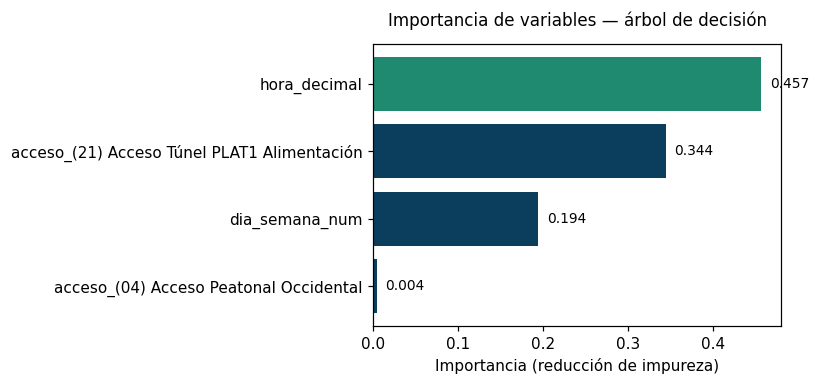

hora_decimal                                   0.457
acceso_(21) Acceso Túnel PLAT1 Alimentación    0.344
dia_semana_num                                 0.194
acceso_(04) Acceso Peatonal Occidental         0.004
dtype: float64


In [13]:
importancias = pd.Series(arbol.feature_importances_, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 3.6))
colores = [TEAL if v == importancias.max() else NAVY for v in importancias.values]
ax.barh(importancias.index, importancias.values, color=colores)
ax.set_xlabel("Importancia (reducción de impureza)")
ax.set_title("Importancia de variables — árbol de decisión", fontsize=11, pad=12)
for i, v in enumerate(importancias.values):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()
print(importancias.sort_values(ascending=False).round(3))


**Interpretación**

- **Qué muestra:** `hora_decimal` concentra la mayor importancia (0,457), seguida por ser o no el acceso Túnel PLAT1 (0,344) y el día de la semana (0,194); el acceso Occidental (04) casi no aporta (0,004) frente a la categoría de referencia (acceso 03).
- **Qué decisión cambiaría:** Si se tuviera que simplificar el modelo a una sola variable por restricciones operativas, sería la hora del día, no el acceso — contrario a lo que sugeriría solo mirar el hallazgo de EDA de que el Túnel PLAT1 concentra la mitad del flujo.
- **Qué limitación tiene:** La importancia de variables de un árbol mide cuánto se usó esa variable para dividir los datos de entrenamiento, no una relación causal; que el acceso 04 tenga importancia casi nula no implica que ese acceso sea irrelevante operativamente, solo que no ayudó a distinguir la etiqueta binaria definida aquí.

### ¿Vale la pena un árbol más profundo? (sobreajuste y complejidad)

Se compara el árbol principal contra uno sin límite de profundidad, mirando **tanto** el conjunto de entrenamiento **como** el de prueba — mirar solo la prueba, como se hizo arriba, no alcanza para hablar de sobreajuste.

In [14]:
arbol_libre = DecisionTreeClassifier(max_depth=None, min_samples_leaf=20, random_state=42)
arbol_libre.fit(X_train, y_train)

filas_comparacion = []
for nombre, modelo in [("Árbol max_depth=5", arbol), ("Árbol sin límite de profundidad", arbol_libre)]:
    acc_tr = accuracy_score(y_train, modelo.predict(X_train))
    acc_te = accuracy_score(y_test, modelo.predict(X_test))
    filas_comparacion.append({
        "modelo": nombre, "hojas": modelo.get_n_leaves(), "profundidad": modelo.get_depth(),
        "exactitud_train": round(acc_tr, 4), "exactitud_test": round(acc_te, 4),
        "brecha_train_test": round(acc_tr - acc_te, 4),
    })
tabla_comparacion = pd.DataFrame(filas_comparacion)
print(tabla_comparacion.to_string(index=False))


                         modelo  hojas  profundidad  exactitud_train  exactitud_test  brecha_train_test
              Árbol max_depth=5     18            5           0.8583          0.8406             0.0178
Árbol sin límite de profundidad    114           13           0.9129          0.8871             0.0258


**Interpretación**

- **Qué muestra:** El árbol sin límite sí prueba mejor en el conjunto de prueba (88,71 % vs. 84,06 %), pero lo hace con 114 hojas en vez de 18 (6 veces más complejo) y con una brecha entrenamiento-prueba mayor (2,58 puntos frente a 1,78 puntos del árbol principal) — es decir, memoriza algo más del mes de entrenamiento de lo que generaliza.
- **Qué decisión cambiaría:** Se elige el árbol de profundidad 5 como modelo principal, no el de mayor exactitud: la ganancia de 4,65 puntos no compensa perder la posibilidad de explicar el modelo en una lámina a un equipo de operación, y una brecha train-test mayor es una señal de alerta, no una garantía de mejor modelo futuro.
- **Qué limitación tiene:** Esta comparación no reproduce el patrón extremo de "fuga de datos" (una exactitud artificialmente cercana al 100 % por usar sin querer información del futuro o del propio target); ambos árboles generalizan de forma razonable. La lección aquí es más sutil: una exactitud mayor no es, por sí sola, razón suficiente para preferir el modelo más complejo cuando el uso es apoyar una decisión humana explicable.

## 7. Segmentación: ¿qué combinaciones (acceso, franja) comparten un perfil de uso?

**Pregunta de negocio:** en vez de mirar acceso y franja por separado, ¿qué grupos naturales aparecen al combinarlos, y qué acción distinta amerita cada grupo?

### Unidad de análisis y variables

Aquí la unidad ya no es la fila individual (`salidas` de un día concreto), sino la **combinación (acceso, franja horaria)** — 443 combinaciones en total — resumida por su comportamiento típico a lo largo del mes. Se construyen tres variables, pensadas para que el agrupamiento no quede dominado por la sola diferencia de escala entre accesos (el Túnel PLAT1 mueve órdenes de magnitud más personas que los accesos de discapacidad):

- **`hora_decimal`**: hora del día de esa franja (0–24).
- **`pct_del_acceso`**: el promedio de esa franja como proporción del promedio general *de su propio acceso* (normaliza la escala: un valor de 1,0 significa "igual al promedio de su acceso").
- **`ratio_finde_semana`**: promedio en fin de semana entre promedio entre semana (con una pequeña constante de suavizado para evitar dividir por cero en franjas de muy bajo volumen); valores por debajo de 1 indican una franja más entre-semana, por encima de 1 una franja más de fin de semana.

In [15]:
grp = datos.groupby(["acceso", "intervalo", "hora_decimal"])
perfil = grp["salidas"].mean().rename("promedio_salidas").reset_index()

prom_finde = datos[datos["es_fin_de_semana"]].groupby(["acceso", "intervalo"])["salidas"].mean().rename("prom_finde")
prom_semana = datos[~datos["es_fin_de_semana"]].groupby(["acceso", "intervalo"])["salidas"].mean().rename("prom_semana")
perfil = perfil.merge(prom_finde, on=["acceso", "intervalo"], how="left")
perfil = perfil.merge(prom_semana, on=["acceso", "intervalo"], how="left")

media_por_acceso = datos.groupby("acceso")["salidas"].mean().rename("media_acceso")
perfil = perfil.merge(media_por_acceso, on="acceso", how="left")
perfil["pct_del_acceso"] = (perfil["promedio_salidas"] / perfil["media_acceso"].replace(0, np.nan)).fillna(0)

EPS = 0.5
perfil["ratio_finde_semana"] = (perfil["prom_finde"] + EPS) / (perfil["prom_semana"] + EPS)

print(f"Combinaciones (acceso, franja) a segmentar: {len(perfil)}")
perfil[["acceso", "intervalo", "hora_decimal", "pct_del_acceso", "ratio_finde_semana"]].describe().round(2)


Combinaciones (acceso, franja) a segmentar: 443


,hora_decimal,pct_del_acceso,ratio_finde_semana
count,443.00,443.00,443.00
mean,12.70,1.00,0.82
std,6.57,2.00,0.34
min,0.00,0.00,0.03
25%,7.25,0.01,0.59
50%,12.75,0.61,0.85
75%,18.25,1.23,1.00
max,23.75,21.42,3.46


**Interpretación**

- **Qué muestra:** 443 combinaciones únicas de (acceso, franja), cada una resumida por su hora, su volumen relativo a su propio acceso y su sesgo entre-semana/fin-de-semana — no filas individuales de un día.
- **Qué decisión cambiaría:** Trabajar a este nivel (y no por fila-día) es lo que permite después nombrar un grupo como 'la franja pico matutina entre semana' y asignarle una acción operativa concreta; agrupar filas-día sueltas mezclaría el mismo acceso y franja en distintos clústeres solo por variación día a día.
- **Qué limitación tiene:** 443 combinaciones es una muestra pequeña para clustering (frente a miles de filas-día); los clústeres resultantes describen patrones típicos del mes, no capturan variabilidad día a día dentro de una misma combinación.

### Escalado y selección de *k* por índice de silueta

Antes de agrupar, se estandarizan las tres variables (misma escala) y se prueba un rango de valores de *k* (número de grupos), usando el **índice de silueta** para decidir cuál produce grupos mejor separados y más cohesionados.

k=2: silueta=0.312, tamaños de grupo=[260, 183]
k=3: silueta=0.348, tamaños de grupo=[219, 6, 218]


k=4: silueta=0.361, tamaños de grupo=[192, 139, 5, 107]


k=5: silueta=0.384, tamaños de grupo=[12, 136, 92, 198, 5]


k=6: silueta=0.343, tamaños de grupo=[112, 88, 98, 5, 8, 132]


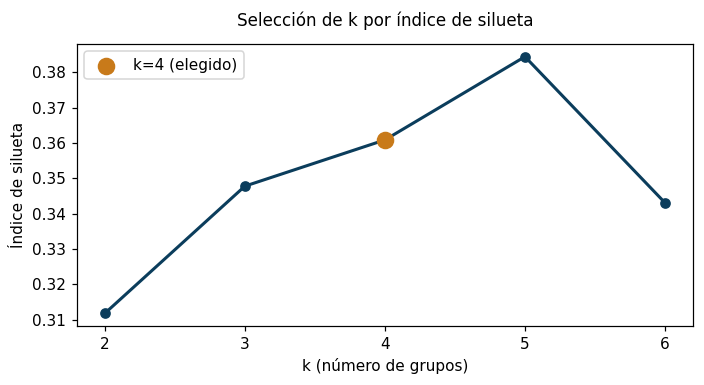

In [16]:
FEATURES = ["hora_decimal", "pct_del_acceso", "ratio_finde_semana"]
X_perfil = perfil[FEATURES].values
X_perfil_esc = StandardScaler().fit_transform(X_perfil)

resultados_k = []
for k in range(2, 7):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas_k = km_k.fit_predict(X_perfil_esc)
    sil_k = silhouette_score(X_perfil_esc, etiquetas_k)
    resultados_k.append({"k": k, "silueta": sil_k, "tamaños": np.bincount(etiquetas_k).tolist()})
    print(f"k={k}: silueta={sil_k:.3f}, tamaños de grupo={np.bincount(etiquetas_k).tolist()}")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ks = [r["k"] for r in resultados_k]
sils = [r["silueta"] for r in resultados_k]
ax.plot(ks, sils, marker="o", color=NAVY, linewidth=2)
ax.scatter([4], [resultados_k[2]["silueta"]], color=AMBER, s=110, zorder=5, label="k=4 (elegido)")
ax.set_xlabel("k (número de grupos)"); ax.set_ylabel("Índice de silueta")
ax.set_title("Selección de k por índice de silueta", fontsize=11, pad=12)
ax.set_xticks(ks)
ax.legend()
plt.tight_layout()
plt.show()


**Interpretación**

- **Qué muestra:** La silueta sube de 0,312 (k=2) a 0,361 (k=4); k=5 da un valor todavía mayor (0,384) pero a costa de dos grupos casi vacíos (12 y 5 combinaciones) que no son segmentos reales, sino ruido aislado. k=6 vuelve a bajar (0,343).
- **Qué decisión cambiaría:** Se elige k=4 en lugar del k=5 de mayor silueta: perseguir la silueta más alta sin mirar el tamaño de los grupos habría producido micro-grupos sin utilidad operativa. Un grupo de negocio necesita un tamaño mínimo para justificar una acción distinta.
- **Qué limitación tiene:** 0,361 es una silueta **moderada, no alta** (por convención, valores por encima de 0,5 se consideran estructura fuerte). Eso ya advierte que los grupos no van a estar perfectamente separados, algo que se confirma más abajo y que se declara explícitamente, no se oculta.

### Ajuste final (k = 4) y perfil de cada grupo

In [17]:
K_FINAL = 4
km = KMeans(n_clusters=K_FINAL, n_init=10, random_state=42)
perfil["cluster"] = km.fit_predict(X_perfil_esc)
silueta_final = silhouette_score(X_perfil_esc, perfil["cluster"])

resumen_clusters = perfil.groupby("cluster").agg(
    n=("cluster", "size"),
    hora_media=("hora_decimal", "mean"),
    pct_del_acceso_medio=("pct_del_acceso", "mean"),
    ratio_finde_medio=("ratio_finde_semana", "mean"),
    salidas_promedio=("promedio_salidas", "mean"),
).round(2)

print(f"Índice de silueta final (k=4): {silueta_final:.3f}")
print(resumen_clusters)
print("\nComposición por acceso (cuántas combinaciones de cada acceso cayeron en cada clúster):")
print(pd.crosstab(perfil["cluster"], perfil["acceso"]))


Índice de silueta final (k=4): 0.361
           n  hora_media  pct_del_acceso_medio  ratio_finde_medio  \
cluster                                                             
0        192       18.84                  0.73               0.81   
1        139        7.15                  0.35               1.10   
2          5       15.75                 16.68               0.15   
3        107        8.76                  1.60               0.51   

         salidas_promedio  
cluster                    
0                   75.89  
1                   19.25  
2                   10.96  
3                  112.38  

Composición por acceso (cuántas combinaciones de cada acceso cayeron en cada clúster):
acceso   (03) Acceso Peatonal Oriental  (04) Acceso Peatonal Occidental  \
cluster                                                                   
0                                   37                               38   
1                                   12                             

**Interpretación**

- **Qué muestra:** Los cuatro grupos tienen tamaños de 192, 139, 107 y 5 combinaciones, con perfiles de hora, volumen relativo y sesgo semana/fin-de-semana claramente distintos entre sí (se detallan y nombran a continuación).
- **Qué decisión cambiaría:** Un grupo de apenas 5 combinaciones (1,1 % del total) es la primera señal de que no los cuatro clústeres numéricos deben tratarse automáticamente como cuatro segmentos de negocio reales — se revisa cada uno antes de proponerle una acción.
- **Qué limitación tiene:** La tabla resume promedios por grupo; dentro de cada grupo sigue habiendo variación combinación a combinación que un promedio no muestra.

In [18]:
print("Detalle de las 5 combinaciones del clúster 2 (para verificar la etiqueta de 'ruido'):")
perfil[perfil["cluster"] == 2][["acceso", "intervalo", "hora_decimal", "promedio_salidas", "pct_del_acceso"]]


Detalle de las 5 combinaciones del clúster 2 (para verificar la etiqueta de 'ruido'):


,acceso,intervalo,hora_decimal,promedio_salidas,pct_del_acceso
240,(18) Acceso Peatonal Oriental (Discapacidad),17:30,17.50,12.666667,16.312195
241,(18) Acceso Peatonal Oriental (Discapacidad),17:45,17.75,15.733333,20.261463
242,(18) Acceso Peatonal Oriental (Discapacidad),18:00,18.00,16.633333,21.420488
243,(18) Acceso Peatonal Oriental (Discapacidad),18:15,18.25,9.533333,12.277073
287,(19) Acceso Peatonal Occidental (Discapacidad),07:15,7.25,0.233333,13.106383


### Nombrando los grupos y su acción operativa

Revisando el perfil completo de cada clúster (no solo su hora promedio, también la dispersión de `pct_del_acceso` y `ratio_finde_semana` y la composición de accesos), se nombran tres segmentos de negocio reales y se señala explícitamente el cuarto como ruido. Se describe cada uno por su rasgo **más consistente** — que no siempre es la hora — para no simplificar de más:

| Clúster | Nombre | Perfil (rasgo que realmente lo define) | Acción propuesta |
|---|---|---|---|
| **3** (n=107) | **Franjas fuertes entre semana (pico matutino)** | Volumen igual o mayor al promedio de su propio acceso (mediana 108 %) y **siempre** más entre-semana que fin de semana (ratio ≤ 0,85 en el 100 % de sus franjas); la hora es mayoritaria pero no exclusivamente matutina (mediana 8:30 a.m., con una cola hasta media tarde). Concentrado en accesos (03), (04) y (21). | Reforzar personal entre semana en esos tres accesos, sobre todo en la mañana — es el segmento de mayor volumen absoluto (≈112 salidas/franja). |
| **0** (n=192) | **Meseta de tarde/noche** | Rasgo más consistente: **nunca** aparece antes del mediodía (rango 12:30 p.m.–11:45 p.m.); volumen relativo y sesgo semana/fin de semana moderados y repartidos de forma pareja **entre los cinco accesos**. | Mantener personal regular distribuido en todos los accesos durante la tarde/noche, en vez de concentrarlo en uno solo — el fenómeno es de toda la estación, no de un acceso puntual. |
| **1** (n=139) | **Valle de bajo volumen** | Rasgo más consistente: volumen relativo a su propio acceso muy bajo (mediana apenas 4 % del promedio de ese acceso); repartido en un rango amplio de horas (no solo la mañana) y sin sesgo fuerte semana/fin de semana. Fuerte peso de los accesos de baja afluencia (18) y (19). | Personal mínimo; candidatas a consolidar turnos o reducir refuerzo, en particular en los accesos de discapacidad, donde el uso es bajo casi todo el día. |
| **2** (n=5) | **Grupo residual / ruido** — *no es un segmento de negocio* | 4 de las 5 combinaciones son franjas de tarde (17:30–18:15) del acceso (18); la quinta es una franja aislada del acceso (19) a las 07:15. `pct_del_acceso` se dispara (12 a 21) y `ratio_finde_semana` colapsa casi a 0 — doblemente extremo, señal de que es un artefacto: estos accesos tienen un promedio tan bajo que cualquier franja algo más alta, dividida por ese promedio casi nulo, se dispara en términos relativos. | No se le asigna una acción operativa como segmento. Si esas franjas puntuales son relevantes, se investigan una por una — agruparlas como "clúster" sería sobre-interpretar 5 de 443 combinaciones (1,1 %). |

Esta tabla responde directamente a la exigencia de la guía: nombrar los grupos y proponer una acción distinta para cada uno, no dejarlos como "salieron cuatro grupos".

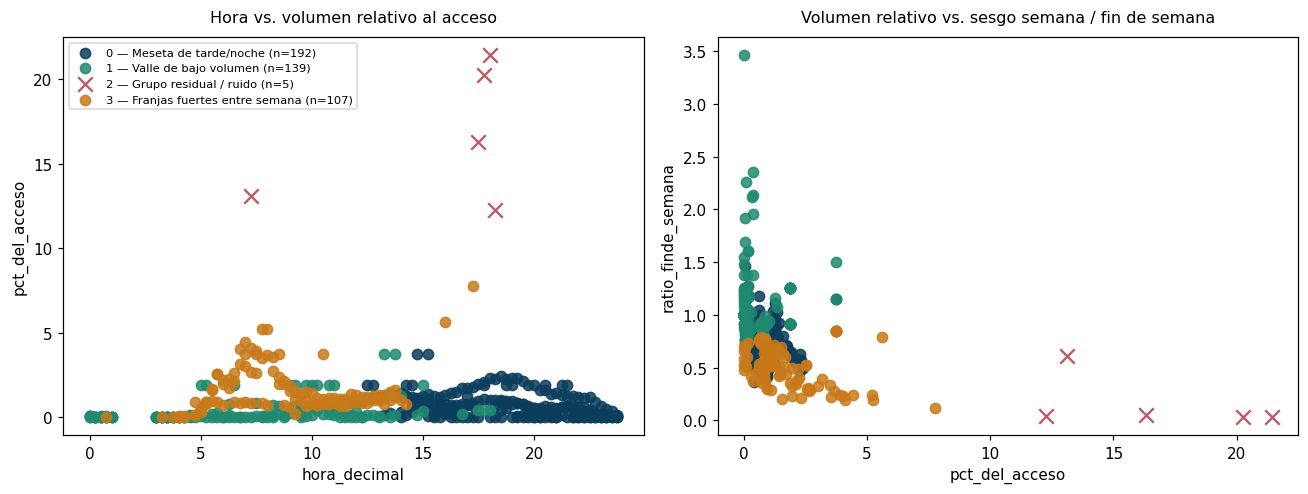

In [19]:
COLORES_CLUSTER = ListedColormap([NAVY, TEAL, "#b23a48", AMBER])
NOMBRES_CLUSTER = {
    3: "Franjas fuertes entre semana", 0: "Meseta de tarde/noche",
    1: "Valle de bajo volumen", 2: "Grupo residual / ruido",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, (fx, fy, titulo) in zip(axes, [
    ("hora_decimal", "pct_del_acceso", "Hora vs. volumen relativo al acceso"),
    ("pct_del_acceso", "ratio_finde_semana", "Volumen relativo vs. sesgo semana / fin de semana"),
]):
    for c in sorted(perfil["cluster"].unique()):
        sub = perfil[perfil["cluster"] == c]
        ax.scatter(sub[fx], sub[fy], label=f"{c} — {NOMBRES_CLUSTER[c]} (n={len(sub)})",
                   color=COLORES_CLUSTER.colors[c], s=45 if c != 2 else 90,
                   marker="o" if c != 2 else "x", alpha=0.85)
    ax.set_xlabel(fx); ax.set_ylabel(fy)
    ax.set_title(titulo, fontsize=10.5, pad=10)
axes[0].legend(fontsize=7.5, loc="upper left")
plt.tight_layout()
plt.show()


**Interpretación**

- **Qué muestra:** Ningún par de variables separa los cuatro grupos por sí solo. En el panel izquierdo, el grupo 0 (meseta) se distingue con claridad porque nunca aparece antes del mediodía, pero los grupos 1 y 3 se traslapan bastante en el eje de la hora. En el panel derecho, el grupo 2 (ruido, 'x') queda aislado en las dos variables a la vez, y ahí sí se ve al grupo 3 separarse de los grupos 0 y 1 por tener siempre un sesgo entre-semana marcado (eje vertical bajo).
- **Qué decisión cambiaría:** Como ningún eje por sí solo explica la separación, la variable que realmente distingue a cada grupo (hora para el grupo 0, volumen relativo para el grupo 1, sesgo semana/fin de semana para el grupo 3) es la que debería guiar la acción operativa de ese grupo, no un promedio genérico de las tres.
- **Qué limitación tiene:** La silueta de 0,361 ya anticipaba esto: los grupos 0, 1 y 3 se traslapan visiblemente en al menos una de las dos vistas. Presentar estos cuatro grupos como categorías nítidamente separadas sería exagerar lo que muestran los datos; se declara la silueta moderada en vez de ocultarla, y el grupo 2 se aísla con claridad en ambos paneles, lo que refuerza por qué se trata aparte como ruido.

## 8. Informe técnico: juicio profesional sobre la puesta en producción

**¿Se recomienda poner estos modelos en producción tal como están?** No en modo autónomo todavía — sí como apoyo a la decisión humana, con condiciones concretas y verificables para escalarlos. A continuación, la justificación con cifras para cada modelo.

### Modelo supervisado (predicción de "alta demanda")

El árbol de decisión (`max_depth=5`) alcanza **84,06 %** de exactitud frente a **72,18 %** de la línea base que siempre predice "no alta demanda" — una mejora real de casi 12 puntos, no cosmética. Pero la matriz de confusión importa más que ese número solo: de las 520 franjas de alta demanda real en la semana de prueba, el modelo detecta 327 (**62,9 % de exhaustividad**) y deja pasar 193 (**37,1 % de falsos negativos**). Para una decisión operativa de reforzar personal preventivamente, dejar pasar 4 de cada 10 picos reales sin alertar es un riesgo que el equipo de operación debe conocer antes de confiar en el modelo sin supervisión.

**Veredicto:** sí, como alerta de apoyo para quien programa turnos — no como disparador automático de decisiones de personal.

**Qué haría falta para confiar más en él:** (1) validar con 2–3 meses adicionales de datos, de temporadas distintas (diciembre/vacaciones vs. mes ordinario), porque hoy el modelo solo vio y solo se probó dentro de noviembre de 2023; (2) mejorar la exhaustividad de la clase minoritaria (ajustando el umbral de decisión o el peso de clases), porque hoy el modelo prioriza no dar falsas alarmas (precisión 75,7 %) a costa de dejar pasar picos reales; (3) acordar con el equipo de operación cuál de los dos errores —falso positivo o falso negativo— es más costoso en la práctica, y calibrar el modelo a ese criterio de negocio y no solo a la exactitud general.

### Modelo no supervisado (segmentación)

La segmentación final (k = 4) obtiene una silueta de **0,361** — una estructura **moderada, no fuerte** (valores por encima de 0,5 suelen considerarse separación clara; este no lo es, y se declara así en vez de presentarlo como una segmentación nítida). Aun con esa limitación, produjo tres segmentos con perfiles operativamente distintos y accionables (franjas fuertes entre semana, con pico matutino: 107 combinaciones, ~112 salidas/franja; meseta de tarde/noche: 192 combinaciones, repartida en los 5 accesos; valle de bajo volumen: 139 combinaciones, concentrado en accesos de baja afluencia) y un cuarto grupo de apenas 5 combinaciones (1,1 % del total) identificado y tratado explícitamente como ruido, no como segmento de negocio.

**Veredicto:** sí, útil para un ejercicio puntual de planeación de turnos por acceso y franja — no para una asignación de personal completamente automatizada, porque la silueta moderada implica fronteras difusas entre grupos (visibles en la dispersión de la Sección 7).

**Qué haría falta para confiar más en él:** (1) revisar manualmente, con el equipo de operación, las combinaciones cercanas a la frontera entre los grupos "meseta" y "valle" antes de fijar políticas rígidas; (2) evaluar si aislar el acceso Túnel PLAT1 (de volumen muy distinto al resto) en un análisis propio mejora la separación, en vez de normalizarlo junto a accesos de volumen casi nulo; (3) no usar nunca el grupo residual para decisiones operativas sin revisar sus 5 franjas una por una.

### Conclusión

Ambos modelos superan con claridad su punto de comparación obligatorio (línea base y estructura al azar) y producen información honesta y accionable, pero ninguno está listo para operar sin supervisión humana: el supervisado necesita más meses de datos y una calibración explícita del costo de cada tipo de error; el no supervisado necesita revisión humana en sus zonas de traslape y debe excluir el grupo residual de cualquier política automática. La recomendación es **adoptarlos ahora como herramientas de apoyo a la decisión** para el próximo ciclo de programación de turnos, con revisión humana, y **reevaluar la puesta en producción plena** una vez cumplidas las condiciones anteriores.

## 9. Reproducibilidad y entrega

- **Ejecución:** este notebook se probó de punta a punta con *Entorno de ejecución → Reiniciar y ejecutar todo*, sin errores. El registro completo de esa ejecución se entrega junto con este archivo.
- **Archivo original:** `raw_portal_eldorado_nov2023.csv` no se modifica en ningún punto del notebook.
- **Archivo depurado:** se genera y se guarda desde la Sección 4 (`sitp_portal_eldorado_depurado_tarea8.csv`), y se entrega junto con este notebook como exige la rúbrica.
- **Cifras:** todas las cifras citadas en las celdas de interpretación y en el informe técnico de la Sección 8 se calculan en vivo en este mismo notebook — ninguna está escrita a mano de forma independiente del código que la produce.
- **Alcance declarado:** los accesos (18) y (19) se excluyen explícitamente del modelo supervisado (Sección 6) por volumen casi nulo; el grupo 2 de la segmentación (Sección 7) se declara como ruido y no como segmento de negocio. Ninguna de estas decisiones se oculta.
- **Entrega:** subir este notebook a Google Colab y compartir el enlace con permiso de "Cualquier persona con el enlace puede ver" (o el equivalente en el repositorio de GitHub del curso), junto con el archivo de datos depurado y el informe técnico, por Blackboard, en la semana 9.